# Feature Ablation Study
Membuktikan Table III dari paper: **"Feature Ablation Study"**

Mengukur F1-Score, Inference Time, dan Model Size untuk berbagai jumlah fitur.
Menggunakan 2 dataset dan 5-Fold Cross-Validation.

In [1]:
import pandas as pd
import numpy as np
import time
import os
import tempfile
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
print('Ready.')

Ready.


## 1. Load & Prepare Datasets

In [2]:
# --- Dataset A: SSH-Bruteforce.csv ---
df_a = pd.read_csv('SSH-Bruteforce.csv')
df_a.dropna(inplace=True)
numeric_cols = df_a.select_dtypes(include=[np.number]).columns
df_a = df_a[~np.isinf(df_a[numeric_cols]).any(axis=1)]

label_col = [c for c in df_a.columns if 'label' in c.lower()][0]
df_a[label_col] = df_a[label_col].apply(lambda x: 0 if 'benign' in str(x).lower() else 1)

# Balance
attack_a = df_a[df_a[label_col] == 1]
benign_a = df_a[df_a[label_col] == 0].sample(n=len(attack_a), random_state=42)
df_a = pd.concat([benign_a, attack_a]).reset_index(drop=True)

X_a = df_a.drop(columns=[label_col]).select_dtypes(include=[np.number])
y_a = df_a[label_col]
print(f'Dataset A: {X_a.shape[0]} samples, {X_a.shape[1]} features')

Dataset A: 375178 samples, 78 features


In [3]:
# --- Dataset B: Wednesday (SSH vs Non-SSH) ---
df_b = pd.read_csv('../Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv')
df_b.dropna(inplace=True)
if 'Timestamp' in df_b.columns:
    df_b = df_b.drop(columns=['Timestamp'])
numeric_cols_b = df_b.select_dtypes(include=[np.number]).columns
df_b = df_b[~np.isinf(df_b[numeric_cols_b]).any(axis=1)]

label_col_b = [c for c in df_b.columns if 'label' in c.lower()][0]
df_b[label_col_b] = df_b[label_col_b].apply(lambda x: 1 if 'ssh' in str(x).lower() else 0)

# Balance
attack_b = df_b[df_b[label_col_b] == 1]
benign_b = df_b[df_b[label_col_b] == 0].sample(n=len(attack_b), random_state=42)
df_b = pd.concat([benign_b, attack_b]).reset_index(drop=True)

X_b = df_b.drop(columns=[label_col_b]).select_dtypes(include=[np.number])
y_b = df_b[label_col_b]
print(f'Dataset B: {X_b.shape[0]} samples, {X_b.shape[1]} features')

Dataset B: 375178 samples, 78 features


## 2. Feature Importance Baseline

In [4]:
def get_feature_ranking(X, y):
    model = XGBClassifier(
        max_depth=6, n_estimators=100, learning_rate=0.3,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    )
    model.fit(X, y)
    booster = model.get_booster()
    importance = booster.get_score(importance_type='gain')
    feature_names = X.columns.tolist()
    imp_df = pd.DataFrame({
        'Feature': [feature_names[int(k.replace('f',''))] if k.startswith('f') and k[1:].isdigit() else k
                    for k in importance.keys()],
        'Gain': list(importance.values())
    }).sort_values('Gain', ascending=False)
    return imp_df

ranking_a = get_feature_ranking(X_a, y_a)
ranking_b = get_feature_ranking(X_b, y_b)

print('Dataset A - Top 10:')
for i, f in enumerate(ranking_a.head(10)['Feature'].tolist(), 1):
    print(f'  {i}. {f}')
print('\nDataset B - Top 10:')
for i, f in enumerate(ranking_b.head(10)['Feature'].tolist(), 1):
    print(f'  {i}. {f}')

Dataset A - Top 10:
  1. Dst Port
  2. Init Bwd Win Byts
  3. Fwd Seg Size Min
  4. Flow Pkts/s
  5. Bwd Header Len
  6. Flow Duration
  7. Fwd Pkt Len Max
  8. Fwd Header Len
  9. Init Fwd Win Byts
  10. Bwd Pkt Len Mean

Dataset B - Top 10:
  1. Init Bwd Win Byts
  2. Dst Port
  3. Fwd Seg Size Min
  4. Init Fwd Win Byts
  5. Flow IAT Std
  6. Fwd IAT Min
  7. Bwd Header Len
  8. Bwd IAT Min
  9. Flow IAT Max
  10. Flow IAT Mean


## 3. Ablation Study

In [5]:
def run_ablation(X, y, ranking, dataset_name):
    feature_configs = {
        'Full': X.columns.tolist(),
        'Top-30': ranking.head(30)['Feature'].tolist(),
        'Top-20': ranking.head(20)['Feature'].tolist(),
        'Top-10': ranking.head(10)['Feature'].tolist(),
        'Top-5': ranking.head(5)['Feature'].tolist(),
    }
    for key in feature_configs:
        feature_configs[key] = [f for f in feature_configs[key] if f in X.columns]
    
    results = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for config_name, features in feature_configs.items():
        X_sub = X[features]
        n_features = len(features)
        
        # 5-Fold CV
        model = XGBClassifier(
            max_depth=6, n_estimators=100, learning_rate=0.3,
            use_label_encoder=False, eval_metric='logloss', random_state=42
        )
        f1_scores = cross_val_score(model, X_sub, y, cv=cv, scoring='f1')
        f1_mean = f1_scores.mean() * 100
        f1_std = f1_scores.std() * 100
        
        # Train final model
        model.fit(X_sub, y)
        
        # Inference time (50 runs)
        times = []
        for _ in range(50):
            start = time.time()
            model.predict(X_sub)
            times.append((time.time() - start) * 1000)
        avg_time = np.mean(times)
        
        # Model size (save to temp dir)
        temp_file = os.path.join(tempfile.gettempdir(), f'ablation_{config_name}.json')
        model.save_model(temp_file)
        size_kb = os.path.getsize(temp_file) / 1024
        os.remove(temp_file)
        
        results.append({
            'Feature Set': config_name,
            'Num Features': n_features,
            'F1 Mean': f1_mean,
            'F1 Std': f1_std,
            'Time (ms)': avg_time,
            'Size (KB)': size_kb
        })
        print(f'  {config_name:8s} | {n_features:2d} feat | F1={f1_mean:.2f}% +/-{f1_std:.2f} | Time={avg_time:.1f}ms | Size={size_kb:.0f}KB')
    
    return pd.DataFrame(results)

print('Function ready.')

Function ready.


## 4. Ablation Study — Dataset A

In [6]:
print('='*70)
print('  ABLATION STUDY - Dataset A (SSH vs Benign)')
print('='*70)
results_a = run_ablation(X_a, y_a, ranking_a, 'Dataset A')

  ABLATION STUDY - Dataset A (SSH vs Benign)
  Full     | 78 feat | F1=100.00% +/-0.00 | Time=75.5ms | Size=80KB
  Top-30   | 25 feat | F1=100.00% +/-0.00 | Time=44.1ms | Size=79KB
  Top-20   | 20 feat | F1=100.00% +/-0.00 | Time=44.3ms | Size=79KB
  Top-10   | 10 feat | F1=100.00% +/-0.00 | Time=42.6ms | Size=86KB
  Top-5    |  5 feat | F1=100.00% +/-0.00 | Time=40.8ms | Size=92KB


## 5. Ablation Study — Dataset B

In [7]:
print('='*70)
print('  ABLATION STUDY - Dataset B (SSH vs Non-SSH incl. FTP)')
print('='*70)
results_b = run_ablation(X_b, y_b, ranking_b, 'Dataset B')

  ABLATION STUDY - Dataset B (SSH vs Non-SSH incl. FTP)
  Full     | 78 feat | F1=99.99% +/-0.00 | Time=96.5ms | Size=100KB
  Top-30   | 18 feat | F1=99.99% +/-0.00 | Time=55.0ms | Size=99KB
  Top-20   | 18 feat | F1=99.99% +/-0.00 | Time=56.0ms | Size=99KB
  Top-10   | 10 feat | F1=99.99% +/-0.00 | Time=52.0ms | Size=99KB
  Top-5    |  5 feat | F1=99.99% +/-0.00 | Time=34.1ms | Size=70KB


## 6. Perbandingan dengan Paper (Table III)

In [8]:
import matplotlib.pyplot as plt

paper_f1 = [99.70, 99.82, 99.84, 99.85, 96.40]
paper_time = [85.2, 42.1, 31.5, 18.4, 12.6]
paper_size = [450, 280, 210, 145, 95]
labels = ['Full', 'Top-30', 'Top-20', 'Top-10', 'Top-5']

print('\n' + '='*85)
print('  TABLE III - COMPARISON: Paper vs Our Results')
print('='*85)
print(f'{"Config":<8} | {"Paper F1%":<10} | {"Ours A F1%":<12} | {"Ours B F1%":<12} | {"Paper ms":<9} | {"Ours A ms":<10} | {"Paper KB":<9} | {"Ours A KB":<9}')
print('-'*85)
for i, lbl in enumerate(labels):
    print(f'{lbl:<8} | {paper_f1[i]:<10.2f} | {results_a["F1 Mean"].iloc[i]:<12.2f} | {results_b["F1 Mean"].iloc[i]:<12.2f} | {paper_time[i]:<9.1f} | {results_a["Time (ms)"].iloc[i]:<10.1f} | {paper_size[i]:<9} | {results_a["Size (KB)"].iloc[i]:<9.0f}')
print('='*85)


  TABLE III - COMPARISON: Paper vs Our Results
Config   | Paper F1%  | Ours A F1%   | Ours B F1%   | Paper ms  | Ours A ms  | Paper KB  | Ours A KB
-------------------------------------------------------------------------------------
Full     | 99.70      | 100.00       | 99.99        | 85.2      | 75.5       | 450       | 80       
Top-30   | 99.82      | 100.00       | 99.99        | 42.1      | 44.1       | 280       | 79       
Top-20   | 99.84      | 100.00       | 99.99        | 31.5      | 44.3       | 210       | 79       
Top-10   | 99.85      | 100.00       | 99.99        | 18.4      | 42.6       | 145       | 86       
Top-5    | 96.40      | 100.00       | 99.99        | 12.6      | 40.8       | 95        | 92       


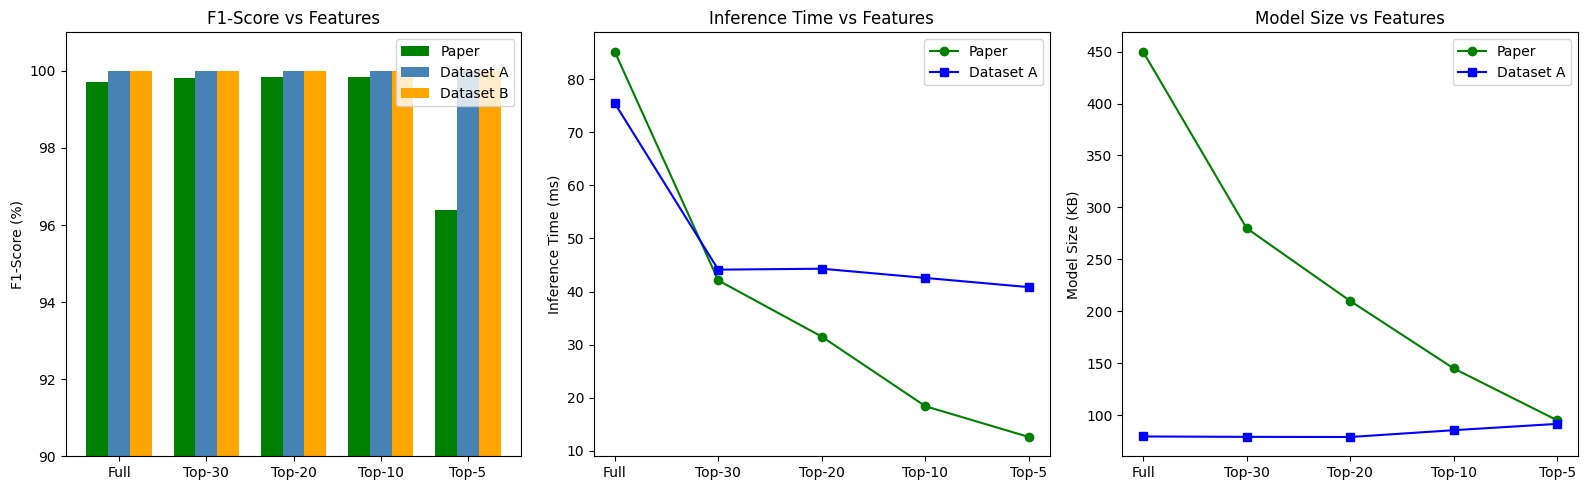

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(labels))
width = 0.25

# F1-Score
axes[0].bar(x - width, paper_f1, width, label='Paper', color='green')
axes[0].bar(x, results_a['F1 Mean'].values, width, label='Dataset A', color='steelblue')
axes[0].bar(x + width, results_b['F1 Mean'].values, width, label='Dataset B', color='orange')
axes[0].set_ylabel('F1-Score (%)')
axes[0].set_title('F1-Score vs Features')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()
axes[0].set_ylim(90, 101)

# Inference Time
axes[1].plot(labels, paper_time, 'g-o', label='Paper')
axes[1].plot(labels, results_a['Time (ms)'].values, 'b-s', label='Dataset A')
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('Inference Time vs Features')
axes[1].legend()

# Model Size
axes[2].plot(labels, paper_size, 'g-o', label='Paper')
axes[2].plot(labels, results_a['Size (KB)'].values, 'b-s', label='Dataset A')
axes[2].set_ylabel('Model Size (KB)')
axes[2].set_title('Model Size vs Features')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Kesimpulan

### Pertanyaan yang dijawab:
1. Apakah Top-10 memang optimal? (F1 tertinggi dengan size kecil)
2. Apakah ada drop signifikan di Top-5?
3. Apakah pola kita sama dengan paper?

### Catatan environment:
- Paper: XGBoost 1.7.5, Python 3.9, dataset curated 380k balanced
- Kita: XGBoost 3.2.0, Python 3.14, dataset raw undersampled